# Loading Datasets

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayanaichatterjee","key":"9daa8c272c121b71cf43abdd98b80521"}'}

In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download abhi8923shriv/sentiment-analysis-dataset

Dataset URL: https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset
License(s): CC0-1.0


In [ ]:
!unzip /content/sentiment-analysis-dataset.zip

Archive:  /content/sentiment-analysis-dataset.zip
  inflating: test.csv                
  inflating: testdata.manual.2009.06.14.csv  
  inflating: train.csv               
  inflating: training.1600000.processed.noemoticon.csv  


# Preparing Dataset

In [ ]:
import pandas as pd

In [ ]:
train = pd.read_csv("/content/train.csv", encoding='ISO-8859-1')

In [ ]:
train.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [ ]:
train.shape

(27481, 10)

In [ ]:
train = train[['text','sentiment']]

In [ ]:
train.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [ ]:
train['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


# converting the label into numericals

In [ ]:
train.isnull().sum()

,0
text,1
sentiment,0


In [ ]:
train.dropna(inplace=True)

In [ ]:
train.isnull().sum()

,0
text,0
sentiment,0


In [ ]:
train.shape

(27480, 2)

# Converting the label from numerical to categorical

In [ ]:
# Define a mapping for the sentiment labels
label_mapping = {'neutral': 1, 'positive': 0, 'negative': 2}

train['sentiment'] = train['sentiment'].map(label_mapping)

In [ ]:
train.head()

,text,sentiment
0,"I`d have responded, if I were going",1
1,Sooo SAD I will miss you here in San Diego!!!,2
2,my boss is bullying me...,2
3,what interview! leave me alone,2
4,"Sons of ****, why couldn`t they put them on t...",2


# Balancing the dataset




In [ ]:
train['sentiment'].value_counts()

,count
sentiment,
1,11117
0,8582
2,7781


In [ ]:
!pip install -q nlpaug nltk

In [ ]:
import pandas as pd
import nlpaug.augmenter.word as naw
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

# Cleaning the dataset

In [ ]:
def clean_text(text):
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

In [ ]:
train['clean_text'] = train['text'].apply(clean_text)

In [ ]:
train.head()

,text,sentiment,clean_text
0,"I`d have responded, if I were going",1,id respond go
1,Sooo SAD I will miss you here in San Diego!!!,2,sooo sad miss san diego
2,my boss is bullying me...,2,boss bulli
3,what interview! leave me alone,2,interview leav alon
4,"Sons of ****, why couldn`t they put them on t...",2,son couldnt put releas alreadi bought


# Convert sentiment to int (if not already)

In [ ]:
train['sentiment'] = train['sentiment'].astype(int)

# Handle class imbalance with augmentation

In [ ]:
augmenter = naw.SynonymAug(aug_src='wordnet')

In [ ]:
def augment_class(df, target_class, target_count):
    current_df = df[df['sentiment'] == target_class]
    augmented_rows = []

    while len(current_df) + len(augmented_rows) < target_count:
        for text in current_df['clean_text']:
            augmented_text = augmenter.augment(text)
            augmented_rows.append({'text': augmented_text, 'sentiment': target_class})
            if len(current_df) + len(augmented_rows) >= target_count:
                break

    return pd.DataFrame(augmented_rows)

# Get class counts

In [ ]:
class_counts = train['sentiment'].value_counts()
max_class = class_counts.max()

# Balance each class

In [ ]:
augmented_dfs = [train]
for sentiment_class, count in class_counts.items():
    if count < max_class:
        augmented = augment_class(train, sentiment_class, max_class)
        augmented_dfs.append(augmented)

In [ ]:
balanced_train = pd.concat(augmented_dfs).reset_index(drop=True)

In [ ]:
balanced_train['sentiment'].value_counts()

,count
sentiment,
1,11117
2,11117
0,11117


In [ ]:
balanced_train.shape

(33351, 3)

In [ ]:
balanced_train.head()

,text,sentiment,clean_text
0,"I`d have responded, if I were going",1,id respond go
1,Sooo SAD I will miss you here in San Diego!!!,2,sooo sad miss san diego
2,my boss is bullying me...,2,boss bulli
3,what interview! leave me alone,2,interview leav alon
4,"Sons of ****, why couldn`t they put them on t...",2,son couldnt put releas alreadi bought


# Ensure no missing clean_text

In [ ]:
balanced_train = balanced_train[balanced_train['clean_text'].notna()]

# Splitting the dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = balanced_train['clean_text']
y = balanced_train['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(21984,)

In [ ]:
X_train.head()

,clean_text
21208,oh he hilari im comment fact he much
18264,thank tri hope bud trillin fest would honor gu...
9683,show hous rock say goodby soon
9688,west coast timegettin readi catch flight back ...
22727,comput slooowww morn think sign go home play yard


In [ ]:
y_train.head()

,sentiment
21208,0
18264,0
9683,1
9688,0
22727,1


# Tokenization

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define the maximum number of words and the sequence length

In [ ]:
max_words = 1000
max_sequence_length = 100

In [ ]:
X_train.head()

,clean_text
21208,oh he hilari im comment fact he much
18264,thank tri hope bud trillin fest would honor gu...
9683,show hous rock say goodby soon
9688,west coast timegettin readi catch flight back ...
22727,comput slooowww morn think sign go home play yard


In [ ]:
y_train.head()

,sentiment
21208,0
18264,0
9683,1
9688,0
22727,1


In [ ]:
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# Convert the texts to sequences (converting words to integers)

In [ ]:
X_train = tokenizer.texts_to_sequences(X_train)

In [ ]:
X_test = tokenizer.texts_to_sequences(X_test)

# Padding the sequences to ensure uniform length

In [ ]:
X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)

In [ ]:
type(X_train)

numpy.ndarray

In [ ]:
y_train

,sentiment
21208,0
18264,0
9683,1
9688,0
22727,1
...,...
21575,1
5390,1
860,1
15795,0


# Training RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
# Build RNN model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),
    SimpleRNN(128, return_sequences=True, dropout=0.3),
    LayerNormalization(),
    SimpleRNN(128, dropout=0.3),
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(3, activation='softmax')
])


In [ ]:
# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=5e-5),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.3602 - loss: 1.5082 - val_accuracy: 0.3120 - val_loss: 1.1642
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.3491 - loss: 1.2913 - val_accuracy: 0.3279 - val_loss: 1.1052
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3624 - loss: 1.1996 - val_accuracy: 0.4014 - val_loss: 1.0931
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3662 - loss: 1.1580 - val_accuracy: 0.4054 - val_loss: 1.0925
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3663 - loss: 1.1405 - val_accuracy: 0.4056 - val_loss: 1.0913
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3717 - loss: 1.1278 - val_accuracy: 0.4063 - val_loss: 1.0900
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3699 - loss: 1.1201 - val_accuracy: 0.4068 - val_loss: 1.0889
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3800 - loss: 1.1072 - val_accuracy: 0.4068 

In [ ]:
# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

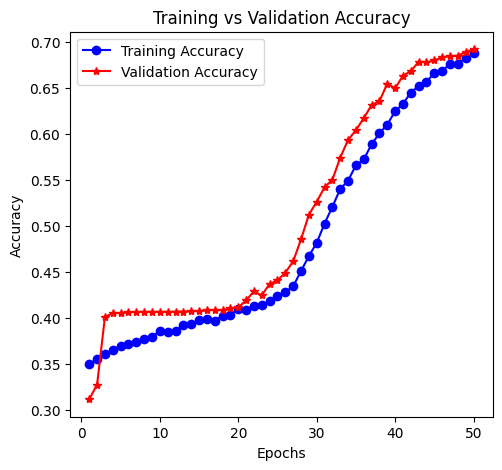

In [ ]:
# Plot Accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

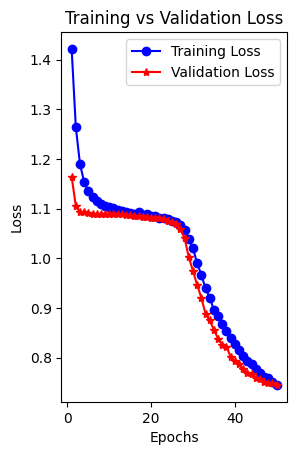

In [ ]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Evaluate

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
y_pred = model.predict(X_test)

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
y_pred[0]

array([0.8768484 , 0.10367138, 0.01948027], dtype=float32)

In [ ]:
y_pred_labels = np.argmax(y_pred, axis=1)

In [ ]:
y_pred_labels

array([0, 2, 1, ..., 1, 1, 1])

In [ ]:
y_test_labels = np.array(y_test).flatten()

In [ ]:
# Print confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1245  393   50]
 [ 294 1680  262]
 [  89  606  877]]


In [ ]:
# Print classification report
report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1688
           1       0.63      0.75      0.68      2236
           2       0.74      0.56      0.64      1572

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



# Training LSTM

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
max_words = 10000
max_sequence_length = 100
embedding_dim = 300

In [ ]:
# Define the model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_sequence_length),
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(128, recurrent_dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test),
                    callbacks=[early_stopping], verbose=1)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.3483 - loss: 1.4901 - val_accuracy: 0.3204 - val_loss: 1.0977
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.3785 - loss: 1.1279 - val_accuracy: 0.4010 - val_loss: 1.0834
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3940 - loss: 1.0987 - val_accuracy: 0.4634 - val_loss: 1.0712
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.4004 - loss: 1.0866 - val_accuracy: 0.4889 - val_loss: 1.0489
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4428 - loss: 1.0574 - val_accuracy: 0.5218 - val_loss: 1.0035
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.4791 - loss: 1.0160 - val_accuracy: 0.5757 - val_loss: 0.9239
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5305 - loss: 0.9510 - val_accuracy: 0.6254 - val_loss: 0.8581
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.5782 - loss: 0.8962 - val_accuracy: 0.6501 - val_loss:

In [ ]:
# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

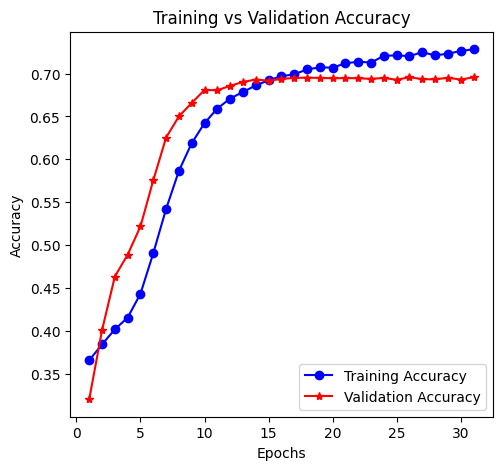

In [ ]:
# Plot Accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

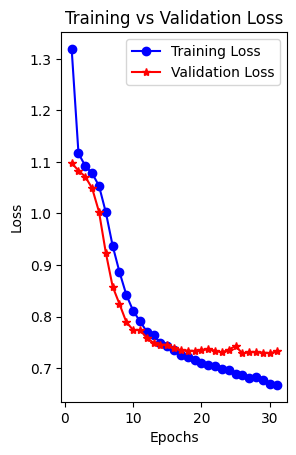

In [ ]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.array(y_test).flatten()

# Print confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:")
print(cm)

# Print classification report
report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:")
print(report)

172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 227ms/step
Confusion Matrix:
[[1266  340   82]
 [ 309 1612  315]
 [ 105  521  946]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1688
           1       0.65      0.72      0.68      2236
           2       0.70      0.60      0.65      1572

    accuracy                           0.70      5496
   macro avg       0.70      0.69      0.70      5496
weighted avg       0.70      0.70      0.70      5496



In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Your label mapping
label_mapping = {'neutral': 1, 'positive': 0, 'negative': 2}
# Create inverse mapping from index to label
index_to_label = {v: k for k, v in label_mapping.items()}

def predict_sentiment(text, model, tokenizer, max_sequence_length=100):
    # Clean text (if you have a function for this)
    text = clean_text(text)

    # Tokenize and pad the input
    sequence = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)

    # Predict
    y_pred = model.predict(padded_sequence)  # shape: (1, 3)
    pred_index = np.argmax(y_pred, axis=1)[0]  # get the predicted class index
    pred_label = index_to_label[pred_index]    # map index to sentiment label
    confidence = float(np.max(y_pred))         # max probability as confidence

    # Add emojis for better readability
    emoji_map = {
        'positive': "😊",
        'neutral': "😐",
        'negative': "😡"
    }

    return f"{pred_label.capitalize()} {emoji_map[pred_label]}", confidence

# Example usage:
test_sentences = [
    "I love this product! It's amazing.",
    "This is the worst service I have ever experienced.",
    "The movie was okay, not great but not terrible either."
]

for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, model, tokenizer)
    print(f"Text: {sentence}\nPredicted Sentiment: {sentiment} (Confidence: {confidence:.4f})\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
Text: I love this product! It's amazing.
Predicted Sentiment: Positive 😊 (Confidence: 0.9725)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
Text: This is the worst service I have ever experienced.
Predicted Sentiment: Negative 😡 (Confidence: 0.8564)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
Text: The movie was okay, not great but not terrible either.
Predicted Sentiment: Positive 😊 (Confidence: 0.4053)



In [ ]:
model.save("lstm_model.h5")

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)